In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import datetime
from datetime import date
sns.set()

In [24]:
data = pd.read_parquet('./final_exploded_data.pq')
data.head()

,grain,County,year_week,retail_mean,retail_median,retail_std,price_mean,price_median,price_std,SV_mean,SV_median,SV_std
0,Beans (Yellow-Green)__-,Bomet,2023-04-03,116.67,116.67,11.006255,100.0,100.0,9.856054,180.0,180.0,1195.78316
1,Beans (Yellow-Green)__-,Bomet,2023-04-10,205.00,205.00,0.000000,200.0,200.0,0.000000,9000.0,9000.0,0.00000
2,Beans (Yellow-Green)__-,Bomet,2023-04-17,106.67,106.67,0.000000,100.0,100.0,0.000000,9000.0,9000.0,0.00000
3,Beans (Yellow-Green)__-,Bomet,2023-04-24,275.00,275.00,0.000000,240.0,240.0,0.000000,12000.0,12000.0,0.00000
4,Beans (Yellow-Green)__-,Bomet,2023-05-01,116.67,116.67,0.000000,100.0,100.0,0.000000,13500.0,13500.0,0.00000


In [25]:
data.columns

Index(['grain', 'County', 'year_week', 'retail_mean', 'retail_median',
       'retail_std', 'price_mean', 'price_median', 'price_std', 'SV_mean',
       'SV_median', 'SV_std'],
      dtype='object')

In [26]:
data.SV_mean.describe()

count    32184.000000
mean      2940.702339
std       2191.658569
min     -19898.882778
25%       1617.881441
50%       2000.037057
75%       3884.108259
max      22308.485124
Name: SV_mean, dtype: float64

In [27]:
target_grain = "Dry Maize__White Maize"
target_counties = ["Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"]

df_target = data[
    (data["grain"] == target_grain) &
    (data["County"].isin(target_counties))
].copy()

In [28]:
base_cols = [
    'retail_mean', 'retail_median', 'retail_std',
    'price_mean', 'price_median', 'price_std',
    'SV_mean', 'SV_median', 'SV_std'
]

for col in base_cols:
    # Global (across counties)
    global_feat = (
        df_target
        .groupby("year_week")[col]
        .mean()
        .reset_index()
        .rename(columns={col: f"global_{col}"})
    )

    for lag in range(1, 4):
        global_feat[f"global_{col}_{lag}"] = global_feat[f"global_{col}"].shift(lag)

    df_target = df_target.merge(
        global_feat.drop(columns=[f"global_{col}"]),
        on="year_week",
        how="left"
    )

    # Local (county-level)
    for lag in range(1, 4):
        df_target[f"local_{col}_{lag}"] = (
            df_target
            .groupby("County")[col]
            .shift(lag)
        )


In [29]:
other_grains = data["grain"].unique().tolist()
other_grains.remove(target_grain)

other_grain_feats = []

for grain in other_grains:
    gdf = data[data["grain"] == grain]

    # Global price signal (across counties)
    weekly_price = (
        gdf
        .groupby("year_week")["price_mean"]
        .mean()
        .reset_index()
        .rename(columns={"price_mean": f"{grain}_price_mean"})
    )

    for lag in range(1, 4):
        weekly_price[f"{grain}_price_mean_{lag}"] = (
            weekly_price[f"{grain}_price_mean"].shift(lag)
        )

    weekly_price = weekly_price.drop(columns=[f"{grain}_price_mean"])
    other_grain_feats.append(weekly_price)


In [30]:
for feat_df in other_grain_feats:
    df_target = df_target.merge(feat_df, on="year_week", how="left")
df_model = df_target.dropna().sort_values("year_week")
df_model["week"] = df_model["year_week"].dt.isocalendar().week
df_model["month"] = df_model["year_week"].dt.month
df_model["quarter"] = df_model["year_week"].dt.quarter
df_model["year"] = df_model["year_week"].dt.year

df_model["sin_week"] = np.sin(2 * np.pi * df_model["week"] / 52)
df_model["cos_week"] = np.cos(2 * np.pi * df_model["week"] / 52)
df_model["sin_month"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["cos_month"] = np.cos(2 * np.pi * df_model["month"] / 12)

In [31]:
y = df_model["price_mean"]

cols_to_drop = [
    'price_mean', 'price_median', 'price_std',
    'retail_mean', 'retail_median', 'retail_std',
    'SV_mean', 'SV_median', 'SV_std',
    'grain', 'week', 'month', 'quarter', 'year'
]

X = df_model.drop(columns=cols_to_drop)
X["County"] = X["County"].astype("category")

In [32]:
X["price_velocity_1"] = X["local_price_mean_1"] - X["local_price_mean_2"]
X["price_velocity_2"] = X["local_price_mean_2"] - X["local_price_mean_3"]
X["price_acceleration"] = X["price_velocity_1"] - X["price_velocity_2"]

X["price_volatility"] = X["local_price_std_1"]
X["retail_volatility"] = X["local_retail_std_1"]

X["local_vs_global_price"] = (
    X["local_price_mean_1"] / (X["global_price_mean_1"] + 1e-6)
)

X["local_vs_global_retail"] = (
    X["local_retail_mean_1"] / (X["global_retail_mean_1"] + 1e-6)
)

X["price_retail_ratio"] = (
    X["local_price_mean_1"] / (X["local_retail_mean_1"] + 1e-6)
)

X["price_trend_3week"] = X["local_price_mean_1"] - X["local_price_mean_3"]
X["retail_trend_3week"] = X["local_retail_mean_1"] - X["local_retail_mean_3"]

X["price_ma_diff"] = X["local_price_mean_1"] - (
    (X["local_price_mean_1"] +
     X["local_price_mean_2"] +
     X["local_price_mean_3"]) / 3
)


In [207]:
target_grain = 'Dry Maize__White Maize'
df = data[data['grain'] == target_grain].copy()


target_counties = ["Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"]
df = df[df["County"].isin(target_counties)].copy()

for col in ['retail_mean', 'retail_median',
       'retail_std', 'price_mean', 'price_median', 'price_std',
       'SV_mean', 'SV_median','SV_std']:
    
    global_price = df.groupby('year_week')[col].mean().reset_index()
    global_price.columns = ['year_week', col]
    for i in range(1, 4):
        global_price[f'global_{col}_{i}'] = global_price[col].shift(i)
        df = pd.merge(df, global_price[['year_week', f'global_{col}_{i}']], on='year_week', how='left')
        df[f'local_{col}_{i}'] = df.groupby('County')[col].shift(i)

# Drop initial NaNs generated by shifting
df = df.dropna()

In [208]:
df.shape

(715, 66)

In [187]:
df_model = df.sort_values('year_week')

df_model['week'] = df_model['year_week'].dt.isocalendar().week
df_model['month'] = df_model['year_week'].dt.month
df_model['quarter'] = df_model['year_week'].dt.quarter
df_model['year'] = df_model['year_week'].dt.year

df_model['sin_week'] = np.sin(2 * np.pi * df_model['week'] / 52)
df_model['cos_week'] = np.cos(2 * np.pi * df_model['week'] / 52)

df_model['sin_month'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['cos_month'] = np.cos(2 * np.pi * df_model['month'] / 12)


# Target = week-over-week change
y = df_model['price_mean']

# Drop columns
cols_to_drop = [
    'price_mean', 'price_median', 'price_std', 
    'retail_mean', 'retail_median', 'retail_std', 
    'SV_mean', 'SV_median', 'SV_std', 
    'grain', 'week', 'month', 'quarter', 'year'
]
X = df_model.drop(columns=cols_to_drop)
X['County'] = X['County'].astype('category')

# Price dynamics
X['price_velocity_1'] = X['local_price_mean_1'] - X['local_price_mean_2']
X['price_velocity_2'] = X['local_price_mean_2'] - X['local_price_mean_3']
X['price_acceleration'] = X['price_velocity_1'] - X['price_velocity_2']

# Volatility features
X['price_volatility'] = X['local_price_std_1']
X['retail_volatility'] = X['local_retail_std_1']

# Ratio features
X['local_vs_global_price'] = X['local_price_mean_1'] / (X['global_price_mean_1'] + 1e-6)
X['local_vs_global_retail'] = X['local_retail_mean_1'] / (X['global_retail_mean_1'] + 1e-6)
X['price_retail_ratio'] = X['local_price_mean_1'] / (X['local_retail_mean_1'] + 1e-6)

# Trend features (comparing lag 1 vs lag 3)
X['price_trend_3week'] = X['local_price_mean_1'] - X['local_price_mean_3']
X['retail_trend_3week'] = X['local_retail_mean_1'] - X['local_retail_mean_3']

# Moving average differences
X['price_ma_diff'] = X['local_price_mean_1'] - ((X['local_price_mean_1'] + X['local_price_mean_2'] + X['local_price_mean_3']) / 3)

In [235]:
df_model['Year_Week'] = df_model['year'].astype(str) + '-' + df_model['week'].astype(str).str.zfill(2)

In [236]:
df_model['Year_Week'].max()

'2025-47'

In [13]:
# Get unique weeks sorted
unique_weeks = sorted(df_model['year_week'].unique())
n_weeks = len(unique_weeks)

print(f"Total weeks in data: {n_weeks}")
print(f"Date range: {unique_weeks[0]} to {unique_weeks[-1]}")

# Split:
# - Train: All data except last 18 weeks
# - Validation: Weeks -18 to -7 (12 weeks for validation)
# - Test: Last 6 weeks (to simulate the competition test set)

train_end_idx = n_weeks - 2
train_weeks = unique_weeks[:train_end_idx]
test_weeks = unique_weeks[train_end_idx:]

print(f"\nTrain weeks: {len(train_weeks)} ({train_weeks[0]} to {train_weeks[-1]})")
print(f"Test weeks: {len(test_weeks)} ({test_weeks[0]} to {test_weeks[-1]})")


Total weeks in data: 148
Date range: 2022-10-24 00:00:00 to 2025-12-22 00:00:00

Train weeks: 146 (2022-10-24 00:00:00 to 2025-12-08 00:00:00)
Test weeks: 2 (2025-12-15 00:00:00 to 2025-12-22 00:00:00)


In [14]:
train_mask = X['year_week'].isin(train_weeks)
test_mask = X['year_week'].isin(test_weeks)

X_train = X[train_mask].drop(columns=['year_week'])
X_test = X[test_mask].drop(columns=['year_week'])

y_train = y[train_mask]
y_test = y[test_mask]

print(f"\nTrain samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


Train samples: 730
Test samples: 10


In [15]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    # n_estimators=200,
    # learning_rate=0.01,          # Lower learning rate
    # num_leaves=31,
    # min_child_samples=20,        # Prevent overfitting
    # subsample=0.8,               # Row sampling
    # colsample_bytree=0.8,        # Column sampling
    # reg_alpha=0.1,               # L1 regularization
    # reg_lambda=0.1,              # L2 regularization
    # min_split_gain=0.01,
    # random_state=42,
    verbosity=1
)

print("\n" + "="*80)
print("TRAINING MODEL")
print("="*80)

lgbm.fit(
    X_train,
    y_train,
    categorical_feature=['County'],
    callbacks=[
        # lgb.early_stopping(stopping_rounds=100, verbose=True),
        # lgb.log_evaluation(period=100)
    ]
)


TRAINING MODEL
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000804 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11861
[LightGBM] [Info] Number of data points in the train set: 730, number of used features: 91
[LightGBM] [Info] Start training from score 55.346438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

LGBMRegressor(verbosity=1)

In [16]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error


actualtest = df_model.loc[X_test.index, 'price_mean']
price_pred_test = lgbm.predict(X_test)

test_mae = mean_absolute_error(actualtest, price_pred_test)
test_rmse = root_mean_squared_error(actualtest, price_pred_test)
test_r2 = r2_score(actualtest, price_pred_test)
test_mape = mean_absolute_percentage_error(actualtest, price_pred_test)

print(f"MAE:  {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²:   {test_r2:.4f}")
print(f"MAPE: {test_mape:.4f}")

MAE:  4.1817
RMSE: 7.4852
R²:   -1.1220
MAPE: 0.0720


In [227]:
# price_pred_test

In [17]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(100).to_string(index=False))

                                  feature  importance
                       price_retail_ratio          71
                       price_acceleration          68
                   Rice__Irr_price_mean_2          64
                       retail_trend_3week          62
                    local_vs_global_price          61
                         price_velocity_2          61
                   local_vs_global_retail          54
    Ground Nuts__Large Brown_price_mean_3          54
     Dry Maize__Yellow Maize_price_mean_1          52
                         global_SV_mean_3          52
                       local_retail_std_1          51
                            price_ma_diff          51
                    Wheat__-_price_mean_2          51
                          local_SV_mean_3          49
  Green Grams__Local-Special_price_mean_2          47
     Beans (Yellow-Green)__-_price_mean_1          45
                          global_SV_std_1          44
Dry Maize__Mixed-Traditional

In [64]:
feature_importance[feature_importance.feature.apply(lambda x:True if 'month' in x else False)]

,feature,importance
58,cos_month,15
57,sin_month,8


# Agri Bora

In [473]:
agri = pd.concat([pd.read_csv('agribora_maize_prices.csv'),  pd.read_csv('agriBORA_maize_prices_weeks_46_to_51.csv')])

In [474]:
agri.sort_values(by = 'Year_Week', inplace=True)

<Axes: xlabel='Year_Week'>

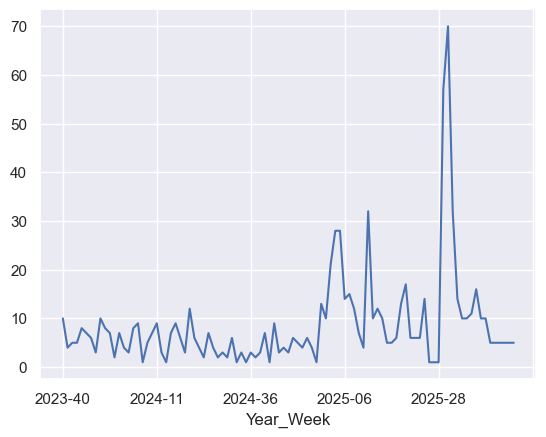

In [475]:
agri.groupby('Year_Week')['Year_Week'].count().plot()

In [476]:
agri.Year_Week.nunique(), agri.County.nunique()

(97, 16)

In [477]:
96*5

480

In [478]:
agri['price_na'] = agri['WholeSale'].isna().astype(int)

<Axes: xlabel='Year_Week'>

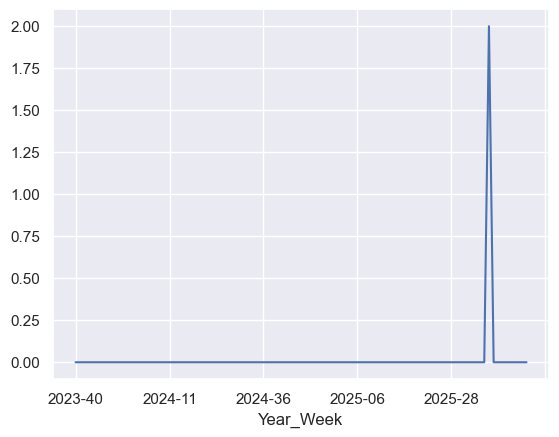

In [479]:
agri.groupby('Year_Week')['price_na'].sum().plot()

In [480]:
agri[agri.price_na == 1]

,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear,price_na
806,Uasin-Gishu,2025-09-24,NaN,Dry_White_Maize,2025-38,39,1
807,Uasin-Gishu,2025-09-26,NaN,Dry_White_Maize,2025-38,39,1


In [481]:
agri = agri[agri.WholeSale.notna()]
agri = agri[agri.County.notna()]

In [482]:
agri.isna().mean()

County                      0.0
Date                        0.0
WholeSale                   0.0
Commodity_Classification    0.0
Year_Week                   0.0
WeekofYear                  0.0
price_na                    0.0
dtype: float64

In [483]:
agri = agri.groupby(['Year_Week', 'County'])['WholeSale'].agg(['mean', 'std']).reset_index()

In [484]:
agri = agri[agri.Year_Week != '2024-00']
agri = agri[agri.Year_Week != '2025-00']

In [485]:
target_counties = ["Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"]
df = agri[agri["County"].isin(target_counties)].copy()

weeks = df['Year_Week'].unique()
counties = target_counties

# Create the full index (The "Ideal" 32k rows)
full_index = pd.MultiIndex.from_product([counties, weeks], names=['County', 'Year_Week'])
df_full = pd.DataFrame(index=full_index).reset_index()
df = pd.merge(df_full, df, on=['County', 'Year_Week'], how='left')

In [486]:
df.isna().mean()

County       0.000000
Year_Week    0.000000
mean         0.502174
std          0.743478
dtype: float64

In [487]:
df.head()

,County,Year_Week,mean,std
0,Kiambu,2023-40,46.67,NaN
1,Kiambu,2023-41,NaN,NaN
2,Kiambu,2023-42,NaN,NaN
3,Kiambu,2023-43,NaN,NaN
4,Kiambu,2023-44,NaN,NaN


In [488]:
df[['mean', 'std']].corr()

,mean,std
mean,1.000000,0.124276
std,0.124276,1.000000


In [489]:
df = df.sort_values(["County", "Year_Week"])

def rolling_fill(df, col, window=5):
    g = df.groupby("County")[col]

    centered = g.transform(
        lambda x: x.rolling(window=window, min_periods=1, center=True).mean()
    )

    fwd = g.transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

    bwd = g.transform(
        lambda x: x[::-1].rolling(window=window, min_periods=1).mean()[::-1]
    )

    out = df[col].copy()
    out = out.fillna(centered)
    out = out.fillna((fwd + bwd) / 2)

    return out

def rolling_fill_forecast_safe(df, col, window=5):
    return (
        df.sort_values(["County", "Year_Week"])
          .groupby("County")[col]
          .transform(
              lambda x: x.fillna(
                  x.rolling(window=window, min_periods=1).mean()
              )
          )
    )

df["mean_filled"] = rolling_fill_forecast_safe(df, "mean", window=5)
df["std_filled"]  = rolling_fill_forecast_safe(df, "std", window=5)

In [490]:
df.isna().mean()

County         0.000000
Year_Week      0.000000
mean           0.502174
std            0.743478
mean_filled    0.300000
std_filled     0.521739
dtype: float64

In [491]:
df["week"] = df["Year_Week"].str[-2:].astype(int)

seasonal_mean = df.groupby(["County", "week"])["mean"].median()
seasonal_std  = df.groupby(["County", "week"])["std"].median()

mean_seasonal_fill = pd.Series(
    df.set_index(["County", "week"]).index.map(seasonal_mean),
    index=df.index
)

std_seasonal_fill = pd.Series(
    df.set_index(["County", "week"]).index.map(seasonal_std),
    index=df.index
)

df["mean_filled"] = df["mean_filled"].fillna(mean_seasonal_fill)
df["std_filled"]  = df["std_filled"].fillna(std_seasonal_fill)

In [492]:
df.isna().mean()

County         0.000000
Year_Week      0.000000
mean           0.502174
std            0.743478
mean_filled    0.169565
std_filled     0.445652
week           0.000000
dtype: float64

In [493]:
df["mean_filled"] = df["mean_filled"].fillna(
    df.groupby(["County"])["mean_filled"].transform("median")
)

df["std_filled"] = df["std_filled"].fillna(
    df.groupby(["County"])["std_filled"].transform("median")
)

In [494]:
df.isna().mean()

County         0.000000
Year_Week      0.000000
mean           0.502174
std            0.743478
mean_filled    0.000000
std_filled     0.000000
week           0.000000
dtype: float64

In [495]:
df = df.drop(['mean', 'std','week'], axis=1)

In [496]:
df

,County,Year_Week,mean_filled,std_filled
0,Kiambu,2023-40,46.670000,0.395980
1,Kiambu,2023-41,46.670000,0.395980
2,Kiambu,2023-42,46.670000,0.395980
3,Kiambu,2023-43,46.670000,0.395980
4,Kiambu,2023-44,46.670000,0.000000
...,...,...,...,...
455,Uasin-Gishu,2025-47,32.777143,0.799670
456,Uasin-Gishu,2025-48,32.554000,0.928693
457,Uasin-Gishu,2025-49,33.334000,0.928693
458,Uasin-Gishu,2025-50,34.888889,1.180868


In [497]:
df = df.rename({'mean_filled':'mean', 'std_filled':'std'}, axis=1)

In [498]:
df.head()

,County,Year_Week,mean,std
0,Kiambu,2023-40,46.67,0.39598
1,Kiambu,2023-41,46.67,0.39598
2,Kiambu,2023-42,46.67,0.39598
3,Kiambu,2023-43,46.67,0.39598
4,Kiambu,2023-44,46.67,0.00000


In [499]:
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer

# tmp = df.copy()
# tmp['std'] = tmp['std'].fillna(-12345)
# tmp['mean'] = tmp['mean'].fillna(-12345)

# df_mean = tmp.pivot_table(
#         index='Year_Week', 
#         columns='County', 
#         values='mean'
# ).rename({x:x+'_mean' for x in target_counties}, axis = 1)
# df_std = tmp.pivot_table(
#         index='Year_Week', 
#         columns='County', 
#         values='std'
# ).rename({x:x+'_std' for x in target_counties}, axis = 1)
# df_both = pd.merge(df_mean, df_std, how = 'inner', on = 'Year_Week')
# df_both = df_both.sort_index(level=['Year_Week'])
# df_both = df_both.replace(-12345, None)
# imputer = IterativeImputer(max_iter=10, random_state=0)


# df_imputed_array = imputer.fit_transform(df_both)
# df_imputed = pd.DataFrame(df_imputed_array, columns=df_both.columns, index=df_both.index)

# df_mean = df_imputed[[x for x in df_imputed.columns if '_mean' in x]].reset_index().melt(
#         id_vars='Year_Week', 
#         var_name='County', 
#         value_name='mean')

# df_mean['County'] = df_mean['County'].str.split('_').str[0]

# df_std = df_imputed[[x for x in df_imputed.columns if '_std' in x]].reset_index().melt(
#         id_vars='Year_Week', 
#         var_name='County', 
#         value_name='std')

# df_std['County'] = df_std['County'].str.split('_').str[0]

# df = pd.merge(df_mean, df_std, on = ['County', 'Year_Week'], how = 'inner')



# def filler(data, col):
#     global df
#     tmp = data.copy()
#     tmp[col] = tmp[col].fillna(-12345)
#     df_pivot = tmp.pivot_table(
#         index='Year_Week', 
#         columns='County', 
#         values=col
#     )
#     df_pivot = df_pivot.sort_index(level=['Year_Week'])
#     df_pivot = df_pivot.replace(-12345, None)
#     imputer = IterativeImputer(max_iter=10, random_state=0)
#     df_imputed_array = imputer.fit_transform(df_pivot)
#     df_imputed = pd.DataFrame(df_imputed_array, columns=df_pivot.columns, index=df_pivot.index)
#     df_clean = df_imputed.reset_index().melt(
#         id_vars='Year_Week', 
#         var_name='County', 
#         value_name=col
#     )
#     df = df.merge(df_clean, how = 'inner', on = ['County', 'Year_Week'])
#     return df

# for col in ['mean', 'std']:
#     df = filler(df, col)

In [500]:
#df = df.rename({'mean_y':'mean', 'std_y':'std'}, axis=1).drop(['mean_x', 'std_x'], axis=1)

In [501]:
df.head()

,County,Year_Week,mean,std
0,Kiambu,2023-40,46.67,0.39598
1,Kiambu,2023-41,46.67,0.39598
2,Kiambu,2023-42,46.67,0.39598
3,Kiambu,2023-43,46.67,0.39598
4,Kiambu,2023-44,46.67,0.00000


In [619]:
for col in ['mean', 'std']:
    global_price = df.groupby('Year_Week')[col].mean().reset_index()
    global_price.columns = ['Year_Week', col]
    for i in range(1, 4):
        global_price[f'global_{col}_{i}'] = global_price[col].shift(i)
        df = pd.merge(df, global_price[['Year_Week', f'global_{col}_{i}']], on='Year_Week', how='left')
        df[f'local_{col}_{i}'] = df.groupby('County')[col].shift(i)

In [645]:
# === STEP 1: Basic date features ===
df['year'] = df['Year_Week'].str.split('-').str[0].astype(int)
df['week'] = df['Year_Week'].str.split('-').str[1].astype(int)
df['date'] = pd.to_datetime(df['Year_Week'] + '-1', format='%G-%V-%u')
df['month'] = df['date'].dt.month

df['sin_week'] = np.sin(2 * np.pi * df['week'] / 52)
df['cos_week'] = np.cos(2 * np.pi * df['week'] / 52)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# === STEP 2: Sort for proper lag calculation ===
df = df.sort_values(['County', 'date']).reset_index(drop=True)

# === STEP 3: Create ALL features on df (before filtering) ===

# Price lags (critical!)
for lag in [1, 2, 3, 7, 14]:
    df[f'price_lag_{lag}'] = df.groupby('County')['mean'].shift(lag)

# Price dynamics (using existing local_mean columns)
df['price_velocity_1'] = df['local_mean_1'] - df['local_mean_2']
df['price_velocity_2'] = df['local_mean_2'] - df['local_mean_3']
df['price_acceleration'] = df['price_velocity_1'] - df['price_velocity_2']

# Ratio features
df['local_vs_global_price'] = df['local_mean_1'] / (df['global_mean_1'] + 1e-6)
df['mean_ratio'] = df['local_mean_1'] / (df['global_mean_1'] + 1e-5)

# Trend features
df['price_trend_3week'] = df['local_mean_1'] - df['local_mean_3']
df['price_ma_diff'] = df['local_mean_1'] - ((df['local_mean_1'] + df['local_mean_2'] + df['local_mean_3']) / 3)

# Volatility features
df['price_volatility'] = df['local_std_1']
df['volatility_ratio'] = df['local_std_1'] / (df['global_std_1'] + 1e-5)
df['cv_local'] = df['local_std_1'] / (df['local_mean_1'] + 1e-5)
df['cv_global'] = df['global_std_1'] / (df['global_mean_1'] + 1e-5)

# Volatility spike (fixed - need groupby)
df['local_std_1_prev'] = df.groupby('County')['local_std_1'].shift(1)
df['volatility_spike'] = (df['local_std_1'] > df['local_std_1_prev'] * 1.3).astype(int)

# Surge detection
df['price_jump'] = df.groupby('County')['mean'].diff()
df['price_jump_std'] = df.groupby('County')['price_jump'].transform(
    lambda x: x.rolling(12, min_periods=4).std()
)
df['is_surge'] = (df['price_jump'].abs() > df['price_jump_std'] * 2).astype(int)

def weeks_since_last_surge(series):
    result = pd.Series(index=series.index, dtype=int)
    last_surge_idx = -999
    for i, (idx, val) in enumerate(series.items()):
        if val == 1:
            last_surge_idx = i
            result[idx] = 0
        else:
            if last_surge_idx == -999:
                result[idx] = 999
            else:
                result[idx] = i - last_surge_idx
    return result

df['weeks_since_surge'] = df.groupby('County')['is_surge'].apply(
    weeks_since_last_surge
).reset_index(level=0, drop=True)

# Momentum features
for period in [1, 2, 4]:
    df[f'price_pct_change_{period}'] = df.groupby('County')['mean'].pct_change(period)

df['momentum_3week'] = df['price_lag_1'] - df['price_lag_3']
df['momentum_strength'] = df['price_velocity_1'] / (df['local_std_1'] + 1e-5)

# Cross features
df['velocity_times_volatility'] = df['price_velocity_1'] * df['local_std_1']
df['trend_strength'] = df['price_trend_3week'] * df['price_acceleration']
df['surge_momentum'] = df['is_surge'] * df['price_velocity_1']

# Moving average crossovers
df['ma_1_3_cross'] = df['local_mean_1'] - df['local_mean_3']
df['ma_global_local_cross'] = df['global_mean_1'] - df['local_mean_1']

# Price position features
df['local_min_3w'] = df.groupby('County')['price_lag_1'].transform(lambda x: x.rolling(3, min_periods=1).min())
df['local_max_3w'] = df.groupby('County')['price_lag_1'].transform(lambda x: x.rolling(3, min_periods=1).max())
df['price_position_3w'] = (df['price_lag_1'] - df['local_min_3w']) / (df['local_max_3w'] - df['local_min_3w'] + 1e-5)
df['dist_from_ma3'] = (df['price_lag_1'] - df['local_mean_3']) / (df['local_std_3'] + 1e-5)

# Lag top features
df['price_ma_diff_lag_1'] = df.groupby('County')['price_ma_diff'].shift(1)
df['price_acceleration_lag_1'] = df.groupby('County')['price_acceleration'].shift(1)
df['local_vs_global_lag_1'] = df.groupby('County')['local_vs_global_price'].shift(1)

# County encoding (careful with target leakage - do this in train/test split)
# For now, use overall mean
county_mean = df.groupby('County')['mean'].mean()
df['county_mean_encoded'] = df['County'].map(county_mean)
county_freq = df['County'].value_counts(normalize=True)
df['county_frequency'] = df['County'].map(county_freq)

print(f"Total features created: {df.shape[1]}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

# === STEP 4: Filter and prepare for modeling ===
# Keep only rows where we have necessary features
df_model = df[df['local_mean_1'].notna()].copy()

# Drop rows with too many NaN from lags
df_model = df_model.dropna(subset=['price_lag_14'])  # Most restrictive lag

print(f"\nRows after filtering: {len(df_model)}/{len(df)}")

# === STEP 5: Create target and features ===
# Target = week-over-week change
y = df_model['mean'] - df_model['local_mean_1']

# Define columns to drop
cols_to_drop = [
    'mean', 'std',  # target and raw std
    'week', 'month', 'year', 'date',  # temporal identifiers
    'local_std_1_prev', 'local_min_3w', 'local_max_3w',  # intermediate calculations
    'price_jump', 'price_jump_std',# intermediate calculations
    'global_mean_1_y', 'global_mean_2_y', 'global_mean_3_y', 
                'global_std_1_y', 'global_std_2_y', 'global_std_3_y'
]

cols_to_drop = ['global_mean_1_y', 'global_mean_2_y', 'global_mean_3_y', 
                'global_std_1_y', 'global_std_2_y', 'global_std_3_y',
                'week', 'Year_Week']  # Also drop identifiers

X_clean = X.drop(columns=[col for col in cols_to_drop if col in X.columns])

X = df_model.drop(columns=[col for col in cols_to_drop if col in df_model.columns])

# Convert County to category
X['County'] = X['County'].astype('category')

print(f"\nFinal feature set: {X.shape[1]} features")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:")
print(X.columns.tolist())

Total features created: 77

Missing values:
price_lag_14                 70
price_lag_7                  35
price_jump_std               20
price_pct_change_4           20
price_acceleration_lag_1     20
price_ma_diff_lag_1          20
price_lag_3                  15
price_acceleration           15
price_velocity_2             15
global_std_3_y               15
global_std_3                 15
global_mean_3_y              15
trend_strength               15
price_trend_3week            15
price_ma_diff                15
global_mean_3                15
dist_from_ma3                15
local_std_3                  15
global_std_3_x               15
momentum_3week               15
local_mean_3                 15
global_mean_3_x              15
ma_1_3_cross                 15
velocity_times_volatility    10
momentum_strength            10
surge_momentum               10
global_std_2                 10
local_std_1_prev             10
local_vs_global_lag_1        10
global_mean_2               

In [646]:
df.head()

,County,Year_Week,mean,std,year,week,date,month,sin_week,cos_week,...,ma_global_local_cross,local_min_3w,local_max_3w,price_position_3w,dist_from_ma3,price_ma_diff_lag_1,price_acceleration_lag_1,local_vs_global_lag_1,county_mean_encoded,county_frequency
0,Kiambu,2023-40,46.67,0.39598,2023,40,2023-10-02,10,-0.992709,0.120537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.85327,0.2
1,Kiambu,2023-41,46.67,0.39598,2023,41,2023-10-09,10,-0.970942,0.239316,...,-1.076,46.67,46.67,0.0,NaN,NaN,NaN,NaN,40.85327,0.2
2,Kiambu,2023-42,46.67,0.39598,2023,42,2023-10-16,10,-0.935016,0.354605,...,-2.225,46.67,46.67,0.0,NaN,NaN,NaN,1.023600,40.85327,0.2
3,Kiambu,2023-43,46.67,0.39598,2023,43,2023-10-23,10,-0.885456,0.464723,...,-3.280,46.67,46.67,0.0,0.0,NaN,NaN,1.050062,40.85327,0.2
4,Kiambu,2023-44,46.67,0.00000,2023,44,2023-10-30,10,-0.822984,0.568065,...,-3.892,46.67,46.67,0.0,0.0,7.105427e-15,0.0,1.075593,40.85327,0.2


In [647]:
df.columns

Index(['County', 'Year_Week', 'mean', 'std', 'year', 'week', 'date', 'month',
       'sin_week', 'cos_week', 'sin_month', 'cos_month', 'global_mean_1_x',
       'local_mean_1', 'global_mean_2_x', 'local_mean_2', 'global_mean_3_x',
       'local_mean_3', 'global_std_1_x', 'local_std_1', 'global_std_2_x',
       'local_std_2', 'global_std_3_x', 'local_std_3', 'price_jump',
       'is_surge', 'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_7',
       'price_lag_14', 'global_mean_1_y', 'global_mean_2_y', 'global_mean_3_y',
       'global_std_1_y', 'global_std_2_y', 'global_std_3_y',
       'price_velocity_1', 'price_velocity_2', 'price_acceleration',
       'global_mean_1', 'global_mean_2', 'global_mean_3', 'global_std_1',
       'global_std_2', 'global_std_3', 'local_vs_global_price', 'mean_ratio',
       'price_trend_3week', 'price_ma_diff', 'price_volatility',
       'volatility_ratio', 'cv_local', 'cv_global', 'local_std_1_prev',
       'volatility_spike', 'price_jump_std', 'we

In [648]:
df_model.isna().mean()

County                      0.0
Year_Week                   0.0
mean                        0.0
std                         0.0
year                        0.0
                           ... 
price_ma_diff_lag_1         0.0
price_acceleration_lag_1    0.0
local_vs_global_lag_1       0.0
county_mean_encoded         0.0
county_frequency            0.0
Length: 77, dtype: float64

In [649]:
# Get unique weeks sorted
unique_weeks = sorted(df_model['Year_Week'].unique())
n_weeks = len(unique_weeks)

print(f"Total weeks in data: {n_weeks}")
print(f"Date range: {unique_weeks[0]} to {unique_weeks[-1]}")

# Split:
# - Train: All data except last 18 weeks
# - Validation: Weeks -18 to -7 (12 weeks for validation)
# - Test: Last 6 weeks (to simulate the competition test set)

train_end_idx = n_weeks - 2
train_weeks = unique_weeks[:train_end_idx]
test_weeks = unique_weeks[train_end_idx:]

print(f"\nTrain weeks: {len(train_weeks)} ({train_weeks[0]} to {train_weeks[-1]})")
print(f"Test weeks: {len(test_weeks)} ({test_weeks[0]} to {test_weeks[-1]})")


Total weeks in data: 78
Date range: 2024-05 to 2025-51

Train weeks: 76 (2024-05 to 2025-49)
Test weeks: 2 (2025-50 to 2025-51)


In [650]:
# year_week_cat = pd.Categorical(X['Year_Week'])
# codes = year_week_cat.codes
# w = (codes - codes.min())/ (codes.max() - codes.min())

In [651]:
train_mask = X['Year_Week'].isin(train_weeks)
test_mask = X['Year_Week'].isin(test_weeks)

X_train = X[train_mask].drop(columns=['Year_Week'])
X_test = X[test_mask].drop(columns=['Year_Week'])

year_week_cat = pd.Categorical(X[X['Year_Week'].isin(train_weeks)]['Year_Week'])
codes = year_week_cat.codes
w = (codes - codes.min())/ (codes.max() - codes.min())

from sklearn.preprocessing import PowerTransformer
scaler = PowerTransformer()

y_train = scaler.fit_transform(y[train_mask].values.reshape(-1, 1)).ravel()
y_test = y[test_mask]

sample_weight = 1 / (np.abs(y_train) + 1e-3)

print(f"\nTrain samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


Train samples: 380
Test samples: 10


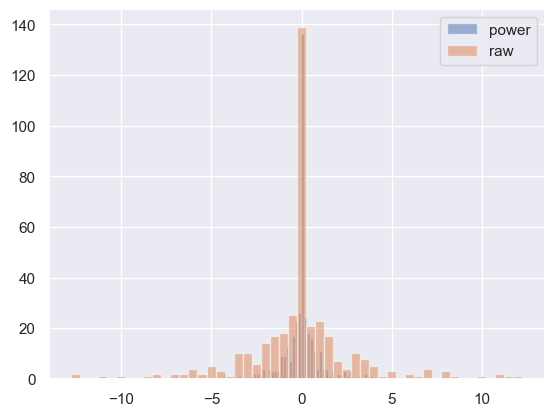

In [652]:
pd.Series(y_train).hist(bins = 50, alpha = 0.5, label = 'power')
y[train_mask].hist(bins = 50, alpha = 0.5, label = 'raw')
plt.legend()

In [653]:
import lightgbm as lgb

# lgbm = lgb.LGBMRegressor(
#     n_estimators=500,
#     # learning_rate=0.01,          # Lower learning rate
#     # num_leaves=125,
#     # min_child_samples=30,        # Prevent overfitting
#     # subsample=0.8,               # Row sampling
#     # colsample_bytree=0.8,        # Column sampling
#     # reg_alpha=0.1,               # L1 regularization
#     # reg_lambda=0.1,              # L2 regularization
#     # min_split_gain=0.0001,
#     # random_state=42,
#     verbosity=1,
#     objective = 'mae'
# )

lgbm = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=0.5,
    objective="regression",
    random_state=42,
    verbosity=-1
)


print("\n" + "="*80)
print("TRAINING MODEL")
print("="*80)

lgbm.fit(
    X_train,
    y_train,
    sample_weight=w,
    categorical_feature=["County"]
)


TRAINING MODEL


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, min_child_samples=30,
              n_estimators=3000, num_leaves=63, objective='regression',
              random_state=42, reg_alpha=0.5, reg_lambda=0.5, subsample=0.8,
              verbosity=-1)

In [654]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error


actualtest = df_model.loc[X_test.index, 'mean']
price_pred_test_diff = lgbm.predict(X_test)
price_pred_test = scaler.inverse_transform(price_pred_test_diff.reshape(-1,1))[0] + X_test['local_mean_1']

test_mae = mean_absolute_error(actualtest, price_pred_test)
test_rmse = root_mean_squared_error(actualtest, price_pred_test)
test_r2 = r2_score(actualtest, price_pred_test)
test_mape = mean_absolute_percentage_error(actualtest, price_pred_test)

print(f"MAE:  {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²:   {test_r2:.4f}")
print(f"MAPE: {test_mape:.4f}")

MAE:  2.3375
RMSE: 2.8360
R²:   0.2981
MAPE: 0.0574


In [655]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.to_string(index=False))

                  feature  importance
       price_pct_change_1         605
       price_pct_change_4         543
    local_vs_global_price         489
       price_pct_change_2         464
         volatility_ratio         406
                 cv_local         331
             local_mean_1         290
        weeks_since_surge         262
    local_vs_global_lag_1         262
             price_lag_14         255
       price_acceleration         244
              price_lag_7         239
           global_std_2_x         224
           trend_strength         219
        price_trend_3week         209
          global_mean_3_x         209
          global_mean_2_x         206
            dist_from_ma3         203
                cv_global         197
 price_acceleration_lag_1         196
             local_mean_2         190
           global_std_3_x         189
           global_std_1_x         168
      price_ma_diff_lag_1         166
              local_std_2         162
            

In [559]:
lgbm.feature_importances_

array([ 186, 1457, 1163,  363,  333, 1283, 1085, 1244, 1260, 1620, 1477,
       1608, 1365, 1817, 1423, 1477, 1303, 1488, 1214, 1829,  302, 2584,
       1462, 1908], dtype=int32)

In [560]:
lgbm.booster_.num_trees()

3000

In [561]:
y

185    0.000000
277   -4.630000
93     0.000000
1      0.000000
369   -1.115000
         ...   
367    3.680556
183    8.333333
91     1.666667
275    5.000000
459    6.777778
Length: 455, dtype: float64

In [562]:
df

,County,Year_Week,mean,std,year,week,date,month,sin_week,cos_week,...,global_mean_2,local_mean_2,global_mean_3,local_mean_3,global_std_1,local_std_1,global_std_2,local_std_2,global_std_3,local_std_3
0,Kiambu,2023-40,46.670000,0.395980,2023,40,2023-10-02,10,-0.992709,0.120537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Kiambu,2023-41,46.670000,0.395980,2023,41,2023-10-09,10,-0.970942,0.239316,...,NaN,NaN,NaN,NaN,0.575832,0.395980,NaN,NaN,NaN,NaN
2,Kiambu,2023-42,46.670000,0.395980,2023,42,2023-10-16,10,-0.935016,0.354605,...,45.594000,46.670000,NaN,NaN,0.921421,0.395980,0.575832,0.395980,NaN,NaN
3,Kiambu,2023-43,46.670000,0.395980,2023,43,2023-10-23,10,-0.885456,0.464723,...,44.445000,46.670000,45.594000,46.670000,1.468722,0.395980,0.921421,0.395980,0.575832,0.395980
4,Kiambu,2023-44,46.670000,0.000000,2023,44,2023-10-30,10,-0.822984,0.568065,...,43.390000,46.670000,44.445000,46.670000,0.604638,0.395980,1.468722,0.395980,0.921421,0.395980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,Uasin-Gishu,2025-47,32.777143,0.799670,2025,47,2025-11-17,11,-0.568065,0.822984,...,41.000333,38.335000,39.481333,38.335000,1.332653,0.751745,0.744400,0.928693,0.802518,0.928693
456,Uasin-Gishu,2025-48,32.554000,0.928693,2025,48,2025-11-24,11,-0.464723,0.885456,...,36.671111,33.222222,41.000333,38.335000,0.778579,0.799670,1.332653,0.751745,0.744400,0.928693
457,Uasin-Gishu,2025-49,33.334000,0.928693,2025,49,2025-12-01,12,-0.354605,0.935016,...,36.571143,32.777143,36.671111,33.222222,0.886596,0.928693,0.778579,0.799670,1.332653,0.751745
458,Uasin-Gishu,2025-50,34.888889,1.180868,2025,50,2025-12-08,12,-0.239316,0.970942,...,36.316300,32.554000,36.571143,32.777143,0.665204,0.928693,0.886596,0.928693,0.778579,0.799670


<Axes: xlabel='date', ylabel='mean'>

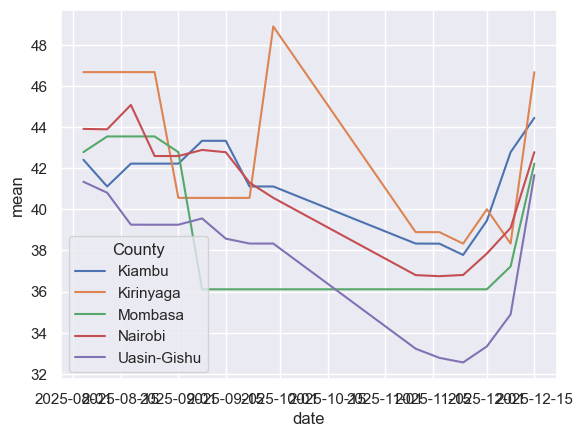

In [563]:
sns.lineplot(x = 'date', y = 'mean', data = df[df['date'] > '2025-08-01'], hue = 'County')

In [564]:
df[(df['County']== 'Kirinyaga') & (df['date'] > '2025-08-01')]

,County,Year_Week,mean,std,year,week,date,month,sin_week,cos_week,...,global_mean_2,local_mean_2,global_mean_3,local_mean_3,global_std_1,local_std_1,global_std_2,local_std_2,global_std_3,local_std_3
169,Kirinyaga,2025-32,46.670000,0.000000,2025,32,2025-08-04,8,-0.663123,-7.485107e-01,...,41.714000,34.440000,42.998750,40.555000,0.765908,0.000000,1.386350,1.576848,1.213757,1.576848
170,Kirinyaga,2025-33,46.670000,0.000000,2025,33,2025-08-11,8,-0.748511,-6.631227e-01,...,44.900819,46.670000,41.714000,34.440000,0.939788,0.000000,0.765908,0.000000,1.386350,1.576848
171,Kirinyaga,2025-34,46.670000,0.000000,2025,34,2025-08-18,8,-0.822984,-5.680647e-01,...,43.421014,46.670000,44.900819,46.670000,0.715436,0.000000,0.939788,0.000000,0.765908,0.000000
172,Kirinyaga,2025-35,46.670000,0.000000,2025,35,2025-08-25,8,-0.885456,-4.647232e-01,...,43.203688,46.670000,43.421014,46.670000,0.858666,0.000000,0.715436,0.000000,0.939788,0.000000
173,Kirinyaga,2025-36,40.555000,1.576848,2025,36,2025-09-01,9,-0.935016,-3.546049e-01,...,43.351800,46.670000,43.203688,46.670000,0.648272,0.000000,0.858666,0.000000,0.715436,0.000000
174,Kirinyaga,2025-37,40.555000,1.576848,2025,37,2025-09-08,9,-0.970942,-2.393157e-01,...,42.854500,46.670000,43.351800,46.670000,0.933026,1.576848,0.648272,0.000000,0.858666,0.000000
175,Kirinyaga,2025-38,40.555000,1.576848,2025,38,2025-09-15,9,-0.992709,-1.205367e-01,...,41.479000,40.555000,42.854500,46.670000,0.743177,1.576848,0.933026,1.576848,0.648272,0.000000
176,Kirinyaga,2025-39,40.555000,1.576848,2025,39,2025-09-22,9,-1.000000,-1.836970e-16,...,40.487400,40.555000,41.479000,40.555000,0.788820,1.576848,0.743177,1.576848,0.933026,1.576848
177,Kirinyaga,2025-40,48.890000,1.576848,2025,40,2025-09-29,9,-0.992709,1.205367e-01,...,40.268571,40.555000,40.487400,40.555000,0.802518,1.576848,0.788820,1.576848,0.743177,1.576848
178,Kirinyaga,2025-46,38.888889,3.146625,2025,46,2025-11-10,11,-0.663123,7.485107e-01,...,39.481333,40.555000,40.268571,40.555000,0.744400,1.576848,0.802518,1.576848,0.788820,1.576848


In [656]:
def build_features_for_week(
    hist_df,
    county,
    target_year,
    target_week,
    override_local_mean_1=None
):
    """
    hist_df: full historical dataframe with all features
    override_local_mean_1: used for recursive prediction
    """
    df_c = hist_df[hist_df['County'] == county].copy()
    
    # Last known weeks
    last = df_c.iloc[-1]
    prev1 = df_c.iloc[-2] if len(df_c) >= 2 else last
    prev2 = df_c.iloc[-3] if len(df_c) >= 3 else prev1
    prev6 = df_c.iloc[-7] if len(df_c) >= 7 else last
    prev13 = df_c.iloc[-14] if len(df_c) >= 14 else last
    
    # Basic means and stds
    local_mean_1 = override_local_mean_1 if override_local_mean_1 is not None else last['mean']
    local_mean_2 = prev1['mean']
    local_mean_3 = prev2['mean']
    local_std_1 = last['std']
    local_std_2 = prev1['std']
    local_std_3 = prev2['std']
    
    # Get global stats (use the non-suffixed version if available, else _x)
    global_mean_1 = last.get('global_mean_1', last.get('global_mean_1_x'))
    global_mean_2 = last.get('global_mean_2', last.get('global_mean_2_x'))
    global_mean_3 = last.get('global_mean_3', last.get('global_mean_3_x'))
    global_std_1 = last.get('global_std_1', last.get('global_std_1_x'))
    global_std_2 = last.get('global_std_2', last.get('global_std_2_x'))
    global_std_3 = last.get('global_std_3', last.get('global_std_3_x'))
    
    # Cyclic features
    sin_week = np.sin(2 * np.pi * target_week / 52)
    cos_week = np.cos(2 * np.pi * target_week / 52)
    month = pd.to_datetime(f"{target_year}-W{target_week}-1", format="%G-W%V-%u").month
    sin_month = np.sin(2 * np.pi * month / 12)
    cos_month = np.cos(2 * np.pi * month / 12)
    
    # Lag features
    price_lag_1 = last['mean']
    price_lag_2 = prev1['mean']
    price_lag_3 = prev2['mean']
    price_lag_7 = prev6['mean']
    price_lag_14 = prev13['mean']
    
    # Price dynamics
    price_velocity_1 = local_mean_1 - local_mean_2
    price_velocity_2 = local_mean_2 - local_mean_3
    price_acceleration = price_velocity_1 - price_velocity_2
    
    # Ratio features
    local_vs_global_price = local_mean_1 / (global_mean_1 + 1e-6)
    mean_ratio = local_mean_1 / (global_mean_1 + 1e-5)
    
    # Trend features
    price_trend_3week = local_mean_1 - local_mean_3
    price_ma_diff = local_mean_1 - ((local_mean_1 + local_mean_2 + local_mean_3) / 3)
    
    # Volatility features
    price_volatility = local_std_1
    volatility_ratio = local_std_1 / (global_std_1 + 1e-5)
    cv_local = local_std_1 / (local_mean_1 + 1e-5)
    cv_global = global_std_1 / (global_mean_1 + 1e-5)
    
    # Volatility spike
    local_std_1_prev = prev1['std']
    volatility_spike = int(local_std_1 > local_std_1_prev * 1.3)
    
    # Surge detection
    price_jump = last['mean'] - prev1['mean']
    recent_jumps = df_c['mean'].diff().tail(12)
    price_jump_std = recent_jumps.std() if len(recent_jumps) > 4 else 1.0
    is_surge = int(abs(price_jump) > price_jump_std * 2)
    
    # Weeks since surge
    weeks_since_surge = 999
    if 'is_surge' in df_c.columns:
        for i in range(min(20, len(df_c))):
            if df_c.iloc[-(i+1)]['is_surge'] == 1:
                weeks_since_surge = i
                break
    
    # Momentum features
    price_pct_change_1 = (last['mean'] - prev1['mean']) / (prev1['mean'] + 1e-5)
    price_pct_change_2 = (prev1['mean'] - prev2['mean']) / (prev2['mean'] + 1e-5)
    prev4 = df_c.iloc[-5]['mean'] if len(df_c) >= 5 else prev2['mean']
    price_pct_change_4 = (last['mean'] - prev4) / (prev4 + 1e-5)
    
    momentum_3week = price_lag_1 - price_lag_3
    momentum_strength = price_velocity_1 / (local_std_1 + 1e-5)
    
    # Cross features
    velocity_times_volatility = price_velocity_1 * local_std_1
    trend_strength = price_trend_3week * price_acceleration
    surge_momentum = is_surge * price_velocity_1
    
    # Moving average crossovers
    ma_1_3_cross = local_mean_1 - local_mean_3
    ma_global_local_cross = global_mean_1 - local_mean_1
    
    # Price position features
    recent_prices = df_c['mean'].tail(3).values
    local_min_3w = recent_prices.min()
    local_max_3w = recent_prices.max()
    price_position_3w = (price_lag_1 - local_min_3w) / (local_max_3w - local_min_3w + 1e-5)
    dist_from_ma3 = (price_lag_1 - local_mean_3) / (local_std_3 + 1e-5)
    
    # Lagged top features
    if 'price_ma_diff' in prev1:
        price_ma_diff_lag_1 = prev1['price_ma_diff']
        price_acceleration_lag_1 = prev1.get('price_acceleration', price_acceleration)
        local_vs_global_lag_1 = prev1.get('local_vs_global_price', local_vs_global_price)
    else:
        # Calculate from scratch
        price_ma_diff_lag_1 = prev1['mean'] - ((prev1['mean'] + prev2['mean'] + df_c.iloc[-4]['mean']) / 3) if len(df_c) >= 4 else 0
        price_acceleration_lag_1 = (prev1['mean'] - prev2['mean']) - (prev2['mean'] - df_c.iloc[-4]['mean']) if len(df_c) >= 4 else 0
        local_vs_global_lag_1 = prev1['mean'] / (global_mean_1 + 1e-6)
    
    # County encoding
    county_mean_encoded = df_c['mean'].mean()
    county_frequency = len(df_c) / len(hist_df)
    
    # Build the row with EXACT column names from your list
    row = {
        'County': county,
        'Year_Week': f"{target_year}-{target_week:02d}",  # Format as YYYY-WW
        'week': target_week,
        'sin_week': sin_week,
        'cos_week': cos_week,
        'sin_month': sin_month,
        'cos_month': cos_month,
        'global_mean_1_x': global_mean_1,
        'local_mean_1': local_mean_1,
        'global_mean_2_x': global_mean_2,
        'local_mean_2': local_mean_2,
        'global_mean_3_x': global_mean_3,
        'local_mean_3': local_mean_3,
        'global_std_1_x': global_std_1,
        'local_std_1': local_std_1,
        'global_std_2_x': global_std_2,
        'local_std_2': local_std_2,
        'global_std_3_x': global_std_3,
        'local_std_3': local_std_3,
        'is_surge': is_surge,
        'price_lag_1': price_lag_1,
        'price_lag_2': price_lag_2,
        'price_lag_3': price_lag_3,
        'price_lag_7': price_lag_7,
        'price_lag_14': price_lag_14,
        'global_mean_1_y': global_mean_1,  # Duplicate
        'global_mean_2_y': global_mean_2,
        'global_mean_3_y': global_mean_3,
        'global_std_1_y': global_std_1,
        'global_std_2_y': global_std_2,
        'global_std_3_y': global_std_3,
        'price_velocity_1': price_velocity_1,
        'price_velocity_2': price_velocity_2,
        'price_acceleration': price_acceleration,
        'global_mean_1': global_mean_1,  # Another duplicate
        'global_mean_2': global_mean_2,
        'global_mean_3': global_mean_3,
        'global_std_1': global_std_1,
        'global_std_2': global_std_2,
        'global_std_3': global_std_3,
        'local_vs_global_price': local_vs_global_price,
        'mean_ratio': mean_ratio,
        'price_trend_3week': price_trend_3week,
        'price_ma_diff': price_ma_diff,
        'price_volatility': price_volatility,
        'volatility_ratio': volatility_ratio,
        'cv_local': cv_local,
        'cv_global': cv_global,
        'volatility_spike': volatility_spike,
        'weeks_since_surge': weeks_since_surge,
        'price_pct_change_1': price_pct_change_1,
        'price_pct_change_2': price_pct_change_2,
        'price_pct_change_4': price_pct_change_4,
        'momentum_3week': momentum_3week,
        'momentum_strength': momentum_strength,
        'velocity_times_volatility': velocity_times_volatility,
        'trend_strength': trend_strength,
        'surge_momentum': surge_momentum,
        'ma_1_3_cross': ma_1_3_cross,
        'ma_global_local_cross': ma_global_local_cross,
        'price_position_3w': price_position_3w,
        'dist_from_ma3': dist_from_ma3,
        'price_ma_diff_lag_1': price_ma_diff_lag_1,
        'price_acceleration_lag_1': price_acceleration_lag_1,
        'local_vs_global_lag_1': local_vs_global_lag_1,
        'county_mean_encoded': county_mean_encoded,
        'county_frequency': county_frequency,
    }
    
    X = pd.DataFrame([row])
    X['County'] = X['County'].astype('category')
    return X

In [667]:
# Save the feature names
train_features = X_train.columns.tolist()
print(f"Training with {len(train_features)} features")


predictions = {}

for county in target_counties:
    # Get historical stats for sanity check
    county_data = df_model[df_model['County'] == county]
    hist_mean = county_data['mean'].mean()
    hist_std = county_data['mean'].std()
    hist_max = county_data['mean'].max()
    hist_min = county_data['mean'].min()
    
    # === WEEK 52 PREDICTION ===
    X_52 = build_features_for_week(
        hist_df=df_model,
        county=county,
        target_year=2025,
        target_week=52
    )
    X_52 = X_52[train_features]  # Ensure feature order
    
    delta_52 = lgbm.predict(X_52)[0]
    mean_51 = county_data.iloc[-1]['mean']
    mean_52 = mean_51 + delta_52
    
    mean_52 = np.clip(mean_52, hist_min - hist_std, hist_max + hist_std)
    predictions[(county, 52)] = mean_52
    
    # === WEEK 53 PREDICTION ===
    X_1 = build_features_for_week(
        hist_df=df_model,
        county=county,
        target_year=2025,
        target_week=1,
        override_local_mean_1=mean_52
    )
    X_1 = X_1[train_features]  # Ensure feature order
    
    delta_1 = lgbm.predict(X_1)[0]
    mean_1 = mean_52 + delta_1
    
    # Clip extreme predictions
    mean_1 = np.clip(mean_1, hist_min - hist_std, hist_max + hist_std)
    
    predictions[(county, 1)] = mean_1

print(f"Total predictions: {len(predictions)}")
print(f"\nSample predictions:")
for (county, week), price in list(predictions.items())[:6]:
    print(f"{county} Week {week}: {price:.2f}")

# Check for any anomalies
pred_df = pd.DataFrame([
    {'County': county, 'Week': week, 'Predicted_Price': price}
    for (county, week), price in predictions.items()
])

print("\n=== Prediction Summary ===")
print(pred_df.groupby('Week')['Predicted_Price'].describe())

Training with 59 features
Total predictions: 10

Sample predictions:
Kiambu Week 52: 45.15
Kiambu Week 1: 45.77
Kirinyaga Week 52: 47.80
Kirinyaga Week 1: 48.89
Mombasa Week 52: 43.63
Mombasa Week 1: 45.01

=== Prediction Summary ===
      count       mean       std        min        25%        50%        75%  \
Week                                                                           
1       5.0  46.012469  1.691176  44.581076  45.014299  45.773496  45.801193   
52      5.0  44.824746  1.830765  43.142042  43.625226  44.402497  45.154409   

            max  
Week             
1     48.892282  
52    47.799556  


In [668]:
predictions

{('Kiambu', 52): 45.154408605714174,
 ('Kiambu', 1): 45.773496131223006,
 ('Kirinyaga', 52): 47.79955592387191,
 ('Kirinyaga', 1): 48.892282485276574,
 ('Mombasa', 52): 43.62522608594573,
 ('Mombasa', 1): 45.01429854705555,
 ('Nairobi', 52): 44.40249680379826,
 ('Nairobi', 1): 45.80119324031362,
 ('Uasin-Gishu', 52): 43.14204219218982,
 ('Uasin-Gishu', 1): 44.581075654624065}

In [669]:
rows = []

for (county, week), pred in predictions.items():
    row_id = f"{county}_Week_{week}"
    rows.append({
        "ID": row_id,
        "Target_RMSE": round(pred, 2),
        "Target_MAE": round(pred, 2)
    })

submission_df = pd.DataFrame(rows)

In [670]:
submission_df

,ID,Target_RMSE,Target_MAE
0,Kiambu_Week_52,45.15,45.15
1,Kiambu_Week_1,45.77,45.77
2,Kirinyaga_Week_52,47.80,47.80
3,Kirinyaga_Week_1,48.89,48.89
4,Mombasa_Week_52,43.63,43.63
5,Mombasa_Week_1,45.01,45.01
6,Nairobi_Week_52,44.40,44.40
7,Nairobi_Week_1,45.80,45.80
8,Uasin-Gishu_Week_52,43.14,43.14
9,Uasin-Gishu_Week_1,44.58,44.58


In [671]:
previous_week = pd.read_csv('agriBORA_maize_prices_weeks_46_to_51.csv')

In [672]:
previous_week['ID'] = previous_week['County'] + '_Week_' + previous_week['WeekofYear'].astype(str)

In [673]:
previous_week['Target_RMSE'] = previous_week['WholeSale']
previous_week['Target_MAE'] = previous_week['WholeSale']

In [674]:
previous_week

,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear,ID,Target_RMSE,Target_MAE
0,Kiambu,2025-11-10,38.333333,Dry_White_Maize,2025-46,46,Kiambu_Week_46,38.333333,38.333333
1,Kirinyaga,2025-11-10,38.888889,Dry_White_Maize,2025-46,46,Kirinyaga_Week_46,38.888889,38.888889
2,Mombasa,2025-11-10,36.111111,Dry_White_Maize,2025-46,46,Mombasa_Week_46,36.111111,36.111111
3,Nairobi,2025-11-10,36.800000,Dry_White_Maize,2025-46,46,Nairobi_Week_46,36.800000,36.800000
4,Uasin-Gishu,2025-11-10,33.222222,Dry_White_Maize,2025-46,46,Uasin-Gishu_Week_46,33.222222,33.222222
5,Kiambu,2025-11-17,38.330000,Dry_White_Maize,2025-47,47,Kiambu_Week_47,38.330000,38.330000
6,Kirinyaga,2025-11-17,38.890000,Dry_White_Maize,2025-47,47,Kirinyaga_Week_47,38.890000,38.890000
7,Mombasa,2025-11-17,36.110000,Dry_White_Maize,2025-47,47,Mombasa_Week_47,36.110000,36.110000
8,Nairobi,2025-11-17,36.748571,Dry_White_Maize,2025-47,47,Nairobi_Week_47,36.748571,36.748571
9,Uasin-Gishu,2025-11-17,32.777143,Dry_White_Maize,2025-47,47,Uasin-Gishu_Week_47,32.777143,32.777143


In [675]:
final_df = pd.concat(
    [previous_week[['ID', 'Target_RMSE', 'Target_MAE']],
     submission_df[['ID', 'Target_RMSE', 'Target_MAE']]],
    axis=0,
    ignore_index=True
)


In [676]:
final_df.to_csv('submission.csv')